<a href="https://colab.research.google.com/github/moham882/Portfolio/blob/main/Copy_of_capstone_refresh_opportunity_scoring.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install duckdb huggingface_hub

from huggingface_hub import login
import getpass

hf_token = getpass.getpass("Enter your Hugging Face read token: ")
login(token=hf_token)

print("Hugging Face login completed.")

Enter your Hugging Face read token: ··········
Hugging Face login completed.


In [ ]:
import duckdb

con = duckdb.connect()

print("DuckDB connected successfully.")

DuckDB connected successfully.


In [ ]:
from huggingface_hub import whoami

info = whoami()
print("Logged in as:", info["name"])

Logged in as: MohammedShaik


In [ ]:
from huggingface_hub import get_token

token = get_token()

print("Token available:", token is not None)

Token available: True


In [ ]:
con.execute(f"""
    CREATE OR REPLACE SECRET hf_secret (
        TYPE HUGGINGFACE,
        TOKEN '{token}'
    )
""")

print("DuckDB Hugging Face authentication configured.")

DuckDB Hugging Face authentication configured.


In [ ]:
REL = "read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet')"

df_check = con.sql(f"""
    SELECT
        MIN(report_date) AS min_date,
        MAX(report_date) AS max_date,
        COUNT(*) AS row_count
    FROM {REL}
""").df()

df_check

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,min_date,max_date,row_count
0,2026-03-01,2026-03-31,9841378


In [ ]:
months = con.sql("""
    SELECT
        month,
        COUNT(*) AS row_count
    FROM read_parquet(
        'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=*/*.parquet'
    )
    GROUP BY month
    ORDER BY month
""").df()

months

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,month,row_count
0,2025-01,1297
1,2025-02,75985
2,2025-03,167859
3,2025-04,285114
4,2025-05,349923
5,2025-06,329201
6,2025-07,469794
7,2025-08,704962
8,2025-09,845813
9,2025-10,2165471


In [ ]:
schema = con.sql("""
    DESCRIBE
    SELECT *
    FROM read_parquet(
        'hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/*.parquet'
    )
""").df()

schema

,column_name,column_type,null,key,default,extra
0,report_date,DATE,YES,None,None,None
1,client_hash_id,VARCHAR,YES,None,None,None
2,content_hash_id,VARCHAR,YES,None,None,None
3,client_has_gsc,BOOLEAN,YES,None,None,None
4,client_has_ga4,BOOLEAN,YES,None,None,None
5,gsc_data_available,BOOLEAN,YES,None,None,None
6,ga4_data_available,BOOLEAN,YES,None,None,None
7,gsc_impressions,BIGINT,YES,None,None,None
8,gsc_clicks,BIGINT,YES,None,None,None
9,gsc_sum_position,BIGINT,YES,None,None,None


In [ ]:
march_content = con.sql(f"""
    SELECT
        content_hash_id,

        SUM(gsc_impressions) AS impressions,
        SUM(gsc_clicks) AS clicks,

        CASE
            WHEN SUM(gsc_impressions) > 0
            THEN SUM(gsc_clicks) * 1.0 / SUM(gsc_impressions)
            ELSE 0
        END AS ctr,

        AVG(gsc_avg_position) AS avg_position,

        SUM(ga4_pageviews) AS pageviews,
        SUM(ga4_sessions) AS sessions,
        SUM(ga4_engaged_sessions) AS engaged_sessions

    FROM {REL}
    GROUP BY content_hash_id
""").df()

march_content.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,content_hash_id,impressions,clicks,ctr,avg_position,pageviews,sessions,engaged_sessions
0,content_b7e512995f79d5a6,1140.0,2.0,0.001754,4.394234,0.0,0.0,0.0
1,content_05597932fe4da067,57.0,0.0,0.000000,2.714744,0.0,0.0,0.0
2,content_905aa32a0230694e,149.0,0.0,0.000000,6.481453,4.0,4.0,0.0
3,content_05434271b257bb68,1421.0,6.0,0.004222,6.320337,12.0,9.0,0.0
4,content_d056587ff7faca0c,2770.0,16.0,0.005776,4.459107,3.0,3.0,0.0


In [ ]:
print("Content items:", len(march_content))
print()

print("March dataset summary:")
print(march_content[[
    "impressions",
    "clicks",
    "ctr",
    "avg_position",
    "pageviews",
    "sessions",
    "engaged_sessions"
]].describe())

Content items: 331437

March dataset summary:
         impressions         clicks            ctr   avg_position  \
count  331437.000000  331437.000000  331437.000000  176738.000000   
mean      846.790156       2.479602       0.002450      15.999277   
std      4044.514753      19.651282       0.027669      17.686260   
min         0.000000       0.000000       0.000000       0.000000   
25%         0.000000       0.000000       0.000000       5.001970   
50%         2.000000       0.000000       0.000000       8.505296   
75%       216.000000       0.000000       0.000000      20.369190   
max    617124.000000    5668.000000       1.000000     309.000000   

           pageviews       sessions  engaged_sessions  
count  260737.000000  260737.000000     260737.000000  
mean        5.694842       4.985131          0.113336  
std        31.822926      28.524165          0.990392  
min         0.000000       0.000000          0.000000  
25%         0.000000       0.000000          0.00000

In [ ]:
thresholds = {
    "total_items": len(march_content),
    "impressions_10": (march_content["impressions"] >= 10).sum(),
    "impressions_50": (march_content["impressions"] >= 50).sum(),
    "impressions_100": (march_content["impressions"] >= 100).sum(),
    "impressions_500": (march_content["impressions"] >= 500).sum(),
    "clicks_positive": (march_content["clicks"] > 0).sum(),
    "position_available": march_content["avg_position"].notna().sum()
}

thresholds

{'total_items': 331437,
 'impressions_10': np.int64(143206),
 'impressions_50': np.int64(116114),
 'impressions_100': np.int64(101441),
 'impressions_500': np.int64(61924),
 'clicks_positive': np.int64(68837),
 'position_available': np.int64(176738)}

In [ ]:
eligible_march = march_content[
    march_content["impressions"] >= 50
].copy()

print("Eligible content items:", len(eligible_march))
print("Minimum impressions:", eligible_march["impressions"].min())

Eligible content items: 116114
Minimum impressions: 50.0


In [ ]:
eligible_march[
    [
        "impressions",
        "clicks",
        "ctr",
        "avg_position",
        "pageviews",
        "sessions",
        "engaged_sessions"
    ]
].describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99])

,impressions,clicks,ctr,avg_position,pageviews,sessions,engaged_sessions
count,116114.000000,116114.000000,116114.000000,116114.000000,85933.000000,85933.000000,85933.000000
mean,2410.185326,7.046144,0.002617,15.498813,16.562299,14.467643,0.327755
std,6552.140362,32.713266,0.004830,15.555164,53.777390,48.280480,1.698022
min,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,182.000000,0.000000,0.000000,5.181502,0.000000,0.000000,0.000000
50%,583.000000,1.000000,0.000858,9.115891,2.000000,2.000000,0.000000
75%,2090.000000,4.000000,0.003454,20.526326,11.000000,9.000000,0.000000
90%,5669.000000,17.000000,0.007194,36.410702,40.000000,34.000000,1.000000
95%,10087.350000,30.000000,0.010811,50.053291,79.000000,68.000000,2.000000
99%,27536.960000,95.000000,0.020350,73.280879,220.000000,198.000000,5.000000


In [ ]:
print("Eligible items:", len(eligible_march))
print(
    "With sessions > 0:",
    (eligible_march["sessions"] > 0).sum()
)
print(
    "With engaged sessions > 0:",
    (eligible_march["engaged_sessions"] > 0).sum()
)
print(
    "With pageviews > 0:",
    (eligible_march["pageviews"] > 0).sum()
)

Eligible items: 116114
With sessions > 0: 59709
With engaged sessions > 0: 12642
With pageviews > 0: 59830


In [ ]:
import pandas as pd

eligible_march["position_band"] = pd.cut(
    eligible_march["avg_position"],
    bins=[0, 3, 5, 10, 20, 50, 100],
    labels=["1-3", "4-5", "6-10", "11-20", "21-50", "51-100"],
    include_lowest=True
)

ctr_position = (
    eligible_march
    .groupby("position_band", observed=True)["ctr"]
    .agg(["count", "median", "mean"])
)

ctr_position

,count,median,mean
position_band,,,
1-3,9687,0.002244,0.003682
4-5,17674,0.002237,0.003749
6-10,34544,0.001331,0.003060
11-20,24294,0.000563,0.002390
21-50,24100,0.000000,0.001464
51-100,5815,0.000000,0.000505


In [ ]:
ctr_benchmark = (
    eligible_march
    .groupby("position_band", observed=True)["ctr"]
    .median()
)

eligible_march["ctr_benchmark"] = (
    eligible_march["position_band"]
    .map(ctr_benchmark)
)

eligible_march["ctr_gap"] = (
    eligible_march["ctr_benchmark"] - eligible_march["ctr"]
).clip(lower=0)

eligible_march[
    [
        "content_hash_id",
        "avg_position",
        "ctr",
        "ctr_benchmark",
        "ctr_gap"
    ]
].head()

,content_hash_id,avg_position,ctr,ctr_benchmark,ctr_gap
0,content_b7e512995f79d5a6,4.394234,0.001754,0.002237,0.000483
1,content_05597932fe4da067,2.714744,0.000000,0.002244,0.002244
2,content_905aa32a0230694e,6.481453,0.000000,0.001331,0.001331
3,content_05434271b257bb68,6.320337,0.004222,0.001331,0.000000
4,content_d056587ff7faca0c,4.459107,0.005776,0.002237,0.000000


In [ ]:
eligible_march["position_opportunity"] = (
    eligible_march["avg_position"]
    .clip(lower=0, upper=50)
)

eligible_march[
    [
        "content_hash_id",
        "avg_position",
        "position_opportunity"
    ]
].head()

,content_hash_id,avg_position,position_opportunity
0,content_b7e512995f79d5a6,4.394234,4.394234
1,content_05597932fe4da067,2.714744,2.714744
2,content_905aa32a0230694e,6.481453,6.481453
3,content_05434271b257bb68,6.320337,6.320337
4,content_d056587ff7faca0c,4.459107,4.459107


In [ ]:
eligible_march["ctr_opportunity_norm"] = (
    eligible_march["ctr_gap"]
    .rank(pct=True)
)

eligible_march["position_opportunity_norm"] = (
    eligible_march["position_opportunity"]
    .rank(pct=True)
)

eligible_march[
    [
        "content_hash_id",
        "ctr_gap",
        "ctr_opportunity_norm",
        "position_opportunity",
        "position_opportunity_norm"
    ]
].head()

,content_hash_id,ctr_gap,ctr_opportunity_norm,position_opportunity,position_opportunity_norm
0,content_b7e512995f79d5a6,0.000483,0.668701,4.394234,0.187471
1,content_05597932fe4da067,0.002244,0.990113,2.714744,0.065255
2,content_905aa32a0230694e,0.001331,0.872453,6.481453,0.346720
3,content_05434271b257bb68,0.000000,0.314415,6.320337,0.335222
4,content_d056587ff7faca0c,0.000000,0.314415,4.459107,0.192500


In [ ]:
eligible_march["opportunity_score"] = (
    0.5 * eligible_march["ctr_opportunity_norm"]
    + 0.5 * eligible_march["position_opportunity_norm"]
)

eligible_march[
    [
        "content_hash_id",
        "ctr_opportunity_norm",
        "position_opportunity_norm",
        "opportunity_score"
    ]
].sort_values(
    "opportunity_score",
    ascending=False
).head(10)

,content_hash_id,ctr_opportunity_norm,position_opportunity_norm,opportunity_score
42872,content_ff649079db06dfb5,0.724353,0.742357,0.733355
292889,content_d4b8f44bbda9fddf,0.724353,0.742339,0.733346
228701,content_787f107e7c94d4b5,0.724353,0.742322,0.733337
301818,content_720b446bf28819a1,0.724353,0.742314,0.733333
297980,content_11c6744f78f3704a,0.724353,0.742279,0.733316
126272,content_f39d84ca3c1b31fd,0.724353,0.742262,0.733307
289199,content_2c3d4519ef2f133a,0.724353,0.742245,0.733299
104188,content_2b4b70cdf07a5b2f,0.724353,0.742227,0.733290
47089,content_5efa758d46c88b7b,0.724353,0.742202,0.733277
238587,content_9cd387f88faa90bc,0.724353,0.742193,0.733273


In [ ]:
top_opportunities = (
    eligible_march
    .sort_values("opportunity_score", ascending=False)
    .head(20)
)

top_opportunities[
    [
        "content_hash_id",
        "impressions",
        "clicks",
        "ctr",
        "avg_position",
        "ctr_benchmark",
        "ctr_gap",
        "opportunity_score"
    ]
]

,content_hash_id,impressions,clicks,ctr,avg_position,ctr_benchmark,ctr_gap,opportunity_score
42872,content_ff649079db06dfb5,392.0,0.0,0.0,19.997860,0.000563,0.000563,0.733355
292889,content_d4b8f44bbda9fddf,81.0,0.0,0.0,19.997222,0.000563,0.000563,0.733346
228701,content_787f107e7c94d4b5,115.0,0.0,0.0,19.996188,0.000563,0.000563,0.733337
301818,content_720b446bf28819a1,624.0,0.0,0.0,19.996152,0.000563,0.000563,0.733333
297980,content_11c6744f78f3704a,246.0,0.0,0.0,19.995286,0.000563,0.000563,0.733316
126272,content_f39d84ca3c1b31fd,126.0,0.0,0.0,19.992938,0.000563,0.000563,0.733307
289199,content_2c3d4519ef2f133a,506.0,0.0,0.0,19.991029,0.000563,0.000563,0.733299
104188,content_2b4b70cdf07a5b2f,559.0,0.0,0.0,19.990757,0.000563,0.000563,0.733290
47089,content_5efa758d46c88b7b,1367.0,0.0,0.0,19.987834,0.000563,0.000563,0.733277
238587,content_9cd387f88faa90bc,62.0,0.0,0.0,19.987821,0.000563,0.000563,0.733273


In [ ]:
score_distribution = pd.cut(
    eligible_march["opportunity_score"],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
    labels=["0-0.2", "0.2-0.4", "0.4-0.6", "0.6-0.8", "0.8-1.0"],
    include_lowest=True
).value_counts().sort_index()

score_distribution

,count
opportunity_score,
0-0.2,4978
0.2-0.4,24957
0.4-0.6,50658
0.6-0.8,35521
0.8-1.0,0


In [ ]:
APRIL_REL = "read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-04/*.parquet')"

april_content = con.sql(f"""
    SELECT
        content_hash_id,
        SUM(gsc_impressions) AS april_impressions,
        SUM(gsc_clicks) AS april_clicks,
        CASE
            WHEN SUM(gsc_impressions) > 0
            THEN SUM(gsc_clicks) * 1.0 / SUM(gsc_impressions)
            ELSE 0
        END AS april_ctr,
        AVG(gsc_avg_position) AS april_avg_position,
        SUM(ga4_sessions) AS april_sessions,
        SUM(ga4_engaged_sessions) AS april_engaged_sessions
    FROM {APRIL_REL}
    GROUP BY content_hash_id
""").df()

print("April content items:", len(april_content))
april_content.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

April content items: 362172


,content_hash_id,april_impressions,april_clicks,april_ctr,april_avg_position,april_sessions,april_engaged_sessions
0,content_ddbfb1907979759a,8.0,0.0,0.0,1.200000,NaN,NaN
1,content_19d31b32f74b4f12,6.0,0.0,0.0,7.375000,NaN,NaN
2,content_92bc8dfb830d0ade,26.0,0.0,0.0,15.380952,NaN,NaN
3,content_2a44e78f3d53769e,17.0,0.0,0.0,2.129630,NaN,NaN
4,content_745efcdf75e0ec8c,7.0,0.0,0.0,6.800000,NaN,NaN


In [ ]:
validation_df = eligible_march.merge(
    april_content,
    on="content_hash_id",
    how="inner"
)

print("Validation items:", len(validation_df))

validation_df[
    [
        "content_hash_id",
        "opportunity_score",
        "impressions",
        "ctr",
        "avg_position",
        "april_impressions",
        "april_clicks",
        "april_ctr",
        "april_avg_position"
    ]
].head()

Validation items: 116114


,content_hash_id,opportunity_score,impressions,ctr,avg_position,april_impressions,april_clicks,april_ctr,april_avg_position
0,content_b7e512995f79d5a6,0.428086,1140.0,0.001754,4.394234,1151.0,2.0,0.001738,5.794221
1,content_05597932fe4da067,0.527684,57.0,0.000000,2.714744,73.0,0.0,0.000000,7.043590
2,content_905aa32a0230694e,0.609586,149.0,0.000000,6.481453,98.0,0.0,0.000000,10.039955
3,content_05434271b257bb68,0.324819,1421.0,0.004222,6.320337,2275.0,30.0,0.013187,4.933878
4,content_d056587ff7faca0c,0.253458,2770.0,0.005776,4.459107,6266.0,6.0,0.000958,7.822087


In [ ]:
validation_df["score_quintile"] = pd.qcut(
    validation_df["opportunity_score"],
    q=5,
    labels=["Q1 Lowest", "Q2", "Q3", "Q4", "Q5 Highest"],
    duplicates="drop"
)

quintile_validation = (
    validation_df
    .groupby("score_quintile", observed=True)
    .agg(
        content_items=("content_hash_id", "count"),
        march_median_score=("opportunity_score", "median"),
        march_median_ctr=("ctr", "median"),
        april_median_ctr=("april_ctr", "median"),
        april_mean_ctr=("april_ctr", "mean"),
        april_median_position=("april_avg_position", "median")
    )
    .reset_index()
)

quintile_validation

,score_quintile,content_items,march_median_score,march_median_ctr,april_median_ctr,april_mean_ctr,april_median_position
0,Q1 Lowest,23225,0.255555,0.004425,0.002683,0.004017,5.711306
1,Q2,23221,0.431873,0.002532,0.001383,0.002690,9.784891
2,Q3,23222,0.541930,0.000366,0.000000,0.001625,16.687333
3,Q4,23223,0.602033,0.000000,0.000000,0.001239,24.792319
4,Q5 Highest,23223,0.663611,0.000000,0.000000,0.001195,18.281498


In [ ]:
q1_mean_ctr = quintile_validation.loc[
    quintile_validation["score_quintile"] == "Q1 Lowest",
    "april_mean_ctr"
].iloc[0]

q5_mean_ctr = quintile_validation.loc[
    quintile_validation["score_quintile"] == "Q5 Highest",
    "april_mean_ctr"
].iloc[0]

ctr_ratio = q1_mean_ctr / q5_mean_ctr
ctr_difference = q1_mean_ctr - q5_mean_ctr

print("Q1 April mean CTR:", q1_mean_ctr)
print("Q5 April mean CTR:", q5_mean_ctr)
print("Q1/Q5 CTR ratio:", ctr_ratio)
print("Absolute CTR difference:", ctr_difference)

Q1 April mean CTR: 0.004016646802873624
Q5 April mean CTR: 0.0011953131561408907
Q1/Q5 CTR ratio: 3.360330121222379
Absolute CTR difference: 0.002821333646732733


In [ ]:
from scipy.stats import spearmanr

spearman_rho, spearman_p = spearmanr(
    validation_df["opportunity_score"],
    validation_df["april_ctr"]
)

print("Spearman correlation:", spearman_rho)
print("p-value:", spearman_p)

Spearman correlation: -0.4677289881092418
p-value: 0.0


In [ ]:
chart_df = quintile_validation[
    [
        "score_quintile",
        "april_mean_ctr"
    ]
].copy()

chart_df

,score_quintile,april_mean_ctr
0,Q1 Lowest,0.004017
1,Q2,0.002690
2,Q3,0.001625
3,Q4,0.001239
4,Q5 Highest,0.001195


In [ ]:
validation_df["baseline_ctr_score"] = (
    -validation_df["ctr"]
).rank(pct=True)

print(
    validation_df[
        ["content_hash_id", "ctr", "baseline_ctr_score"]
    ].head()
)

            content_hash_id       ctr  baseline_ctr_score
0  content_b7e512995f79d5a6  0.001754            0.395758
1  content_05597932fe4da067  0.000000            0.783114
2  content_905aa32a0230694e  0.000000            0.783114
3  content_05434271b257bb68  0.004222            0.206267
4  content_d056587ff7faca0c  0.005776            0.137068


In [ ]:
from scipy.stats import spearmanr

baseline_rho, baseline_p = spearmanr(
    validation_df["baseline_ctr_score"],
    validation_df["april_ctr"]
)

print("Baseline Spearman correlation:", baseline_rho)
print("Baseline p-value:", baseline_p)

Baseline Spearman correlation: -0.5119105370512268
Baseline p-value: 0.0


In [ ]:
comparison = pd.DataFrame({
    "method": [
        "CTR-only baseline",
        "Combined opportunity score"
    ],
    "spearman_rho": [
        baseline_rho,
        spearman_rho
    ]
})

comparison

,method,spearman_rho
0,CTR-only baseline,-0.511911
1,Combined opportunity score,-0.467729


In [ ]:
print("eligible_march:", "eligible_march" in globals())
print("april_content:", "april_content" in globals())
print("validation_df:", "validation_df" in globals())

eligible_march: False
april_content: False
validation_df: False


In [124]:
from pathlib import Path
import re

html = Path("docs/index.html").read_text(encoding="utf-8")

matches = re.findall(
    r'<figure[^>]*>.*?assets/april_ctr_by_score_quintile\.png.*?</figure>',
    html,
    flags=re.IGNORECASE | re.DOTALL
)

print("Chart figure found:", bool(matches))

if matches:
    print("\nExact chart HTML:\n")
    print(matches[0])
else:
    print("\nNo chart figure found in the HTML.")

Chart figure found: True

Exact chart HTML:

<figure class="chart-card">
  <img
    src="assets/april_ctr_by_score_quintile.png"
    alt="Mean April CTR by March opportunity-score quintile"
    loading="lazy"
  >
  <figcaption>
    Mean April CTR by March opportunity-score quintile. Higher March opportunity
    scores are associated with weaker subsequent April CTR.
  </figcaption>
</figure>


In [125]:
from pathlib import Path
import subprocess

files_to_check = [
    "docs/index.html",
    "docs/assets/april_ctr_by_score_quintile.png",
    "work/capstone_report.md",
    "submission/paper_url.txt",
]

for f in files_to_check:
    path = Path(f)
    print(
        ("✓" if path.exists() else "✗"),
        f,
        f"({path.stat().st_size:,} bytes)" if path.exists() else ""
    )

print("\nGit status:")
print(subprocess.check_output(
    ["git", "status", "--short"],
    text=True
))

✓ docs/index.html (22,064 bytes)
✓ docs/assets/april_ctr_by_score_quintile.png (62,968 bytes)
✓ work/capstone_report.md (15,384 bytes)
✓ submission/paper_url.txt (35 bytes)

Git status:
?? docs/assets/
?? docs/index.html
?? work/capstone_report.md
?? work/outputs/



In [126]:
import subprocess

subprocess.run(
    ["git", "add",
     "docs/index.html",
     "docs/assets/april_ctr_by_score_quintile.png",
     "work/capstone_report.md",
     "work/outputs/"],
    check=True
)

print("✓ Capstone files staged")
print("\nStaged changes:")
print(subprocess.check_output(
    ["git", "status", "--short"],
    text=True
))

✓ Capstone files staged

Staged changes:
A  docs/assets/april_ctr_by_score_quintile.png
A  docs/index.html
A  work/capstone_report.md
A  work/outputs/april_ctr_by_score_quintile.png



In [128]:
import subprocess

result = subprocess.run(
    ["git", "commit", "-m", "Add refresh opportunity scoring capstone paper"],
    capture_output=True,
    text=True
)

print("Return code:", result.returncode)
print("\nSTDOUT:")
print(result.stdout)

print("\nSTDERR:")
print(result.stderr)

Return code: 128

STDOUT:


STDERR:
Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@9902b92008eb.(none)')



In [129]:
import subprocess

subprocess.run(
    ["git", "config", "user.name", "Mohammed Ibrahim"],
    check=True
)

subprocess.run(
    ["git", "config", "user.email", "mohammedibrahim0627@gmail.com"],
    check=True
)

print("✓ Git identity configured")

print("Name:", subprocess.check_output(
    ["git", "config", "user.name"], text=True
).strip())

print("Email:", subprocess.check_output(
    ["git", "config", "user.email"], text=True
).strip())

✓ Git identity configured
Name: Mohammed Ibrahim
Email: mohammedibrahim0627@gmail.com


In [130]:
import subprocess

result = subprocess.run(
    ["git", "commit", "-m", "Add refresh opportunity scoring capstone paper"],
    capture_output=True,
    text=True
)

print(result.stdout)
print(result.stderr)

if result.returncode == 0:
    print("✓ Capstone commit created successfully")

[main dce698c] Add refresh opportunity scoring capstone paper
 4 files changed, 563 insertions(+)
 create mode 100644 docs/assets/april_ctr_by_score_quintile.png
 create mode 100644 docs/index.html
 create mode 100644 work/capstone_report.md
 create mode 100644 work/outputs/april_ctr_by_score_quintile.png


✓ Capstone commit created successfully


In [132]:
import subprocess

result = subprocess.run(
    ["gh", "auth", "status"],
    capture_output=True,
    text=True
)

print("Return code:", result.returncode)
print("\nSTDOUT:")
print(result.stdout)

print("\nSTDERR:")
print(result.stderr)

Return code: 1

STDOUT:


STDERR:
You are not logged into any GitHub hosts. To log in, run: gh auth login



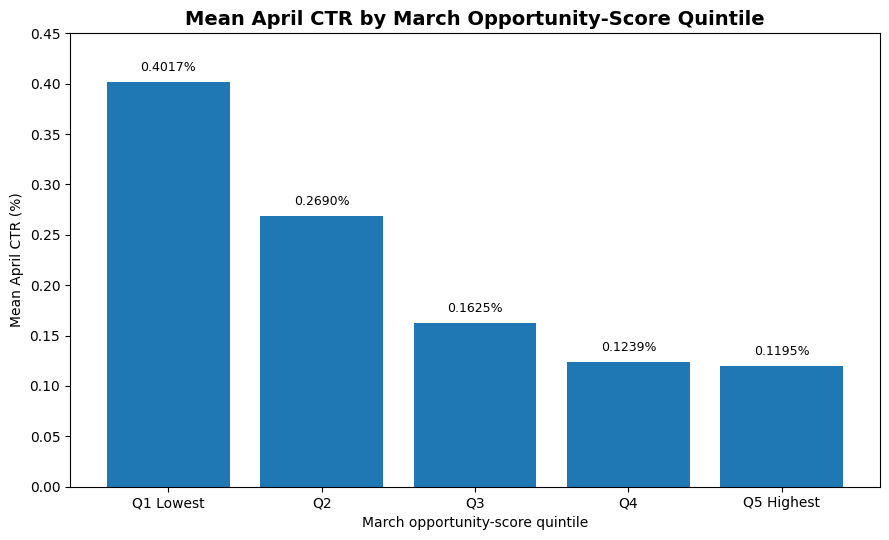

✓ Chart saved to: work/outputs/april_ctr_by_score_quintile.png


In [136]:
import matplotlib.pyplot as plt

# Derived validation results
quintiles = [
    "Q1 Lowest",
    "Q2",
    "Q3",
    "Q4",
    "Q5 Highest"
]

april_mean_ctr = [
    0.401665,
    0.268955,
    0.162490,
    0.123894,
    0.119531
]

# Create bar chart
plt.figure(figsize=(9, 5.5))

bars = plt.bar(quintiles, april_mean_ctr)

plt.title(
    "Mean April CTR by March Opportunity-Score Quintile",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("March opportunity-score quintile")
plt.ylabel("Mean April CTR (%)")

plt.ylim(0, 0.45)

# Add values above bars
for bar, value in zip(bars, april_mean_ctr):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.008,
        f"{value:.4f}%",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()

# Save for your report
output_path = "work/outputs/april_ctr_by_score_quintile.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")

plt.show()

print(f"✓ Chart saved to: {output_path}")